# 导入库和数据准备

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import make_classification

# 生成模拟数据

In [2]:
# 生成模拟的二分类数据
# 使用make_classification函数生成可分离的数据
X, y = make_classification(
    n_samples=500,        # 生成500个样本
    n_features=2,         # 每个样本有2个特征（方便可视化）
    n_informative=2,      # 2个特征都是有用的信息特征
    n_redundant=0,        # 没有冗余特征
    n_clusters_per_class=1,  # 每个类别只有1个簇
    random_state=42       # 随机种子，确保结果可重复
)
print("数据生成完成")
print("样本数:", X.shape[0], "特征数:", X.shape[1])
print("类别0:", np.sum(y == 0), "类别1:", np.sum(y == 1))

数据生成完成
样本数: 500 特征数: 2
类别0: 249 类别1: 251


# 可视化数据分布

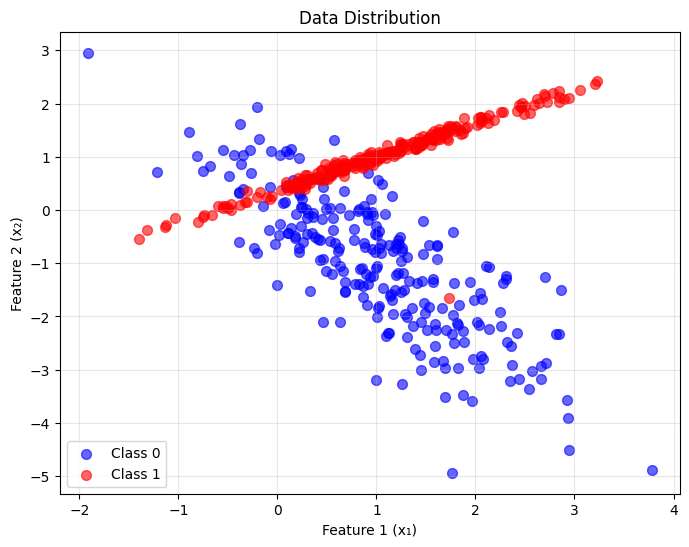

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], 
            c='blue', label='Class 0', alpha=0.6, s=50)
plt.scatter(X[y == 1, 0], X[y == 1, 1], 
            c='red', label='Class 1', alpha=0.6, s=50)
plt.xlabel('Feature 1 (x₁)')
plt.ylabel('Feature 2 (x₂)')
plt.title('Data Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 划分测试集与训练集

先线性组合，再通过Sigmoid函数  
z = w·x + b  
y = sigmoid(z) = 1 / (1 + exp(-z))  
y被限制在 (0, 1) 区间，表示概率  
用于分类问题，输出是"属于正类的概率"  
逻辑回归用的损失函数是交叉熵损失  
loss = -[y_true*log(y_pred) + (1-y_true)*log(1-y_pred)]  
衡量概率分布的差异  
当y_true=1时：loss = -log(y_pred)  
当y_true=0时：loss = -log(1-y_pred)  

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)
#与线性回归一样
print("数据划分完成")
print("训练集:", X_train.shape[0], "个样本")
print("测试集:", X_test.shape[0], "个样本")

数据划分完成
训练集: 400 个样本
测试集: 100 个样本


# 创建并训练逻辑回归模型

In [21]:
# 创建逻辑回归模型，使用lbfgs优化器
model = LogisticRegression( # 创建逻辑回归模型对象
    solver='lbfgs', # 指定优化算法
    max_iter=1000, # 最大迭代次数限制
    random_state=42
)
# 训练模型
model.fit(X_train, y_train) # 用训练数据拟合模型
print("模型训练完成")
print("   权重 w:", [round(coef, 4) for coef in model.coef_[0]])
print("   截距 b:", round(model.intercept_[0], 4))

模型训练完成
   权重 w: [np.float64(0.255), np.float64(2.1639)]
   截距 b: -0.6117


# 模型预测

In [20]:
# 预测测试集
y_pred = model.predict(X_test)  
y_pred_prob = model.predict_proba(X_test)

# 模型评估

In [22]:
# 计算准确率和混淆矩阵
accuracy = accuracy_score(y_test, y_pred) #准确率 = (正确预测的样本数) / (总样本数)
conf_matrix = confusion_matrix(y_test, y_pred) #混淆矩阵
print("   准确率:", round(accuracy, 4))
print("   混淆矩阵:")
print("   ", conf_matrix[0])
print("   ", conf_matrix[1])
# 从混淆矩阵计算更多指标
TN, FP, FN, TP = conf_matrix.ravel()
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
print("   精确率:", round(precision, 4)) #预测为正类的样本中，真正是正类的比例（准确）
print("   召回率:", round(recall, 4)) #实际为正类的样本中，被正确预测的比例（全面）
print("   F1分数:", round(f1, 4)) #精确率和召回率的调和平均数 2 × (精确率 × 召回率) / (精确率 + 召回率)

   准确率: 0.89
   混淆矩阵:
    [42  8]
    [ 3 47]
   精确率: 0.8545
   召回率: 0.94
   F1分数: 0.8952


# 可视化决策边界
决策边界是模型在特征空间中划定的"分界线"，用于区分不同类别，就是模型认为的类别分界线。

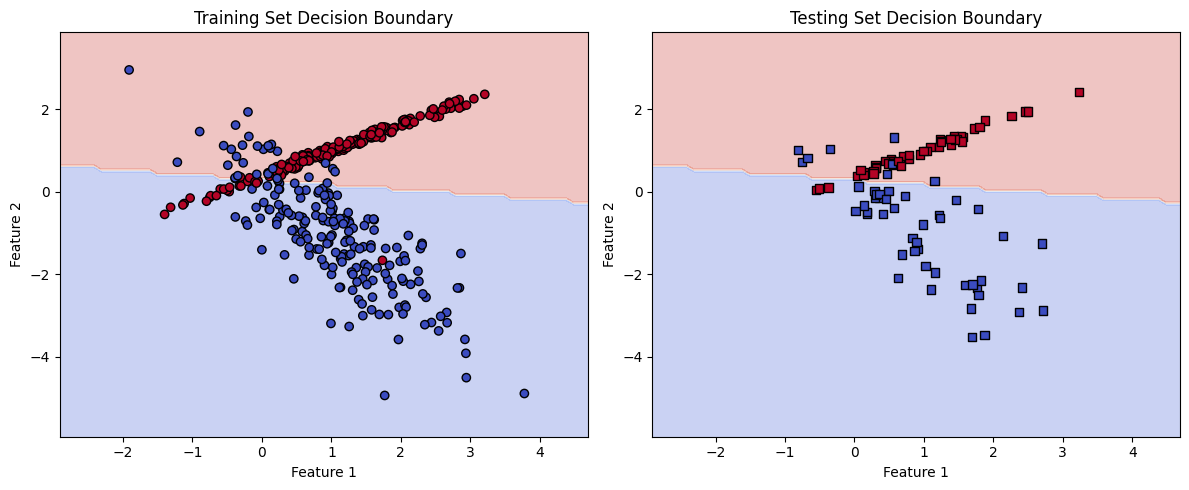

In [29]:
# 创建网格用于绘制决策边界
# 获取特征1（x轴）的最小值和最大值，并向外扩展1个单位
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
# 对应的特征值2（y轴）
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
# 创建网格点：生成覆盖整个数据范围的坐标网格
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# 预测网格上每个点的类别
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
# 创建包含两个子图的图形
plt.figure(figsize=(12, 5))
# 子图1：训练集的决策边界
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap='coolwarm')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Set Decision Boundary')
# 子图2：测试集的决策边界
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap='coolwarm', marker='s')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Testing Set Decision Boundary')
plt.tight_layout()
plt.show()

# Sigmoid函数可视化

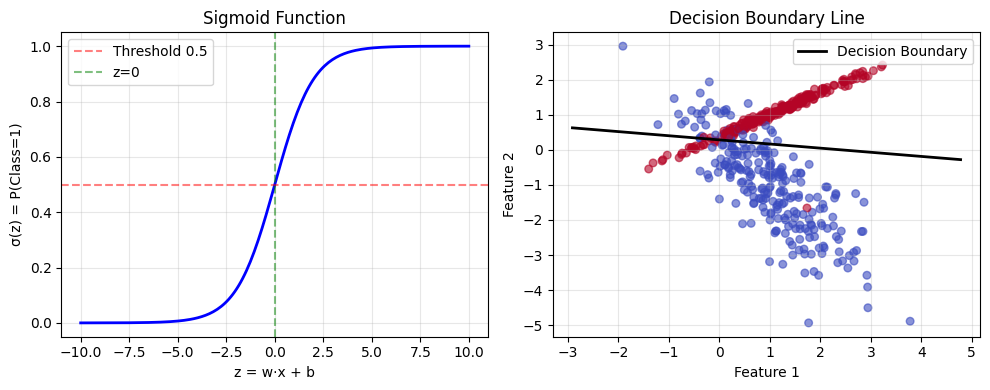

In [25]:
# 定义Sigmoid函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
# 生成Sigmoid函数的数据点
z_values = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z_values)
# 获取模型参数用于绘制决策边界线
w = model.coef_[0]
b = model.intercept_[0]
# 创建包含两个子图的图形
plt.figure(figsize=(10, 4))
# 子图1：Sigmoid函数曲线
plt.subplot(1, 2, 1)
plt.plot(z_values, sigmoid_values, 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Threshold 0.5')
plt.axvline(x=0, color='g', linestyle='--', alpha=0.5, label='z=0')
plt.xlabel('z = w·x + b')
plt.ylabel('σ(z) = P(Class=1)')
plt.title('Sigmoid Function')
plt.grid(True, alpha=0.3)
plt.legend()
# 子图2：决策边界线
plt.subplot(1, 2, 2)
# 绘制所有数据点
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.6, cmap='coolwarm', s=30)
# 计算并绘制决策边界线（z=0的线）
x1_line = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])
x2_line = (-w[0] * x1_line - b) / w[1]
plt.plot(x1_line, x2_line, 'k-', linewidth=2, label='Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary Line')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 新样本预测

In [26]:
# 使用训练好的模型预测新样本
print("12. 新样本预测")
new_samples = np.array([
    [1.5, -0.5],   # 样本1
    [-0.5, 1.5],   # 样本2
    [0.0, 0.0]     # 样本3
])
new_pred = model.predict(new_samples)
new_prob = model.predict_proba(new_samples)
for i in range(len(new_samples)):
    print("   样本" + str(i+1) + ":")
    print("     特征: " + str(new_samples[i]))
    print("     P(类别=0): " + str(round(new_prob[i, 0], 3)))
    print("     P(类别=1): " + str(round(new_prob[i, 1], 3)))
    print("     预测类别: " + str(new_pred[i]))

12. 新样本预测
   样本1:
     特征: [ 1.5 -0.5]
     P(类别=0): 0.788
     P(类别=1): 0.212
     预测类别: 0
   样本2:
     特征: [-0.5  1.5]
     P(类别=0): 0.075
     P(类别=1): 0.925
     预测类别: 1
   样本3:
     特征: [0. 0.]
     P(类别=0): 0.648
     P(类别=1): 0.352
     预测类别: 0
